In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

df_mortalidad = pd.read_parquet("mortalidad_limpio.parquet")

df_mortalidad = df_mortalidad[df_mortalidad['ANO'] < 2026]

CLASIFICACION_CRONICAS    Diabetes  Enfermedades Cerebrovasculares  \
REGIMEN_SEGURIDAD_SOCIAL                                             
Contributivo                  5964                           39526   
Especial                        20                             220   
Excepción                      502                            2366   
No Asegurado                   576                            4346   
Sin Información                 52                            2172   
Subsidiado                    4798                           24460   

CLASIFICACION_CRONICAS    Enfermedades Cronicas De Las Vias Respiratorias Inferiores  \
REGIMEN_SEGURIDAD_SOCIAL                                                               
Contributivo                                                           3466            
Especial                                                                 14            
Excepción                                                               252            

C:\Users\Eliel David\AppData\Local\Temp\ipykernel_14228\1289538452.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


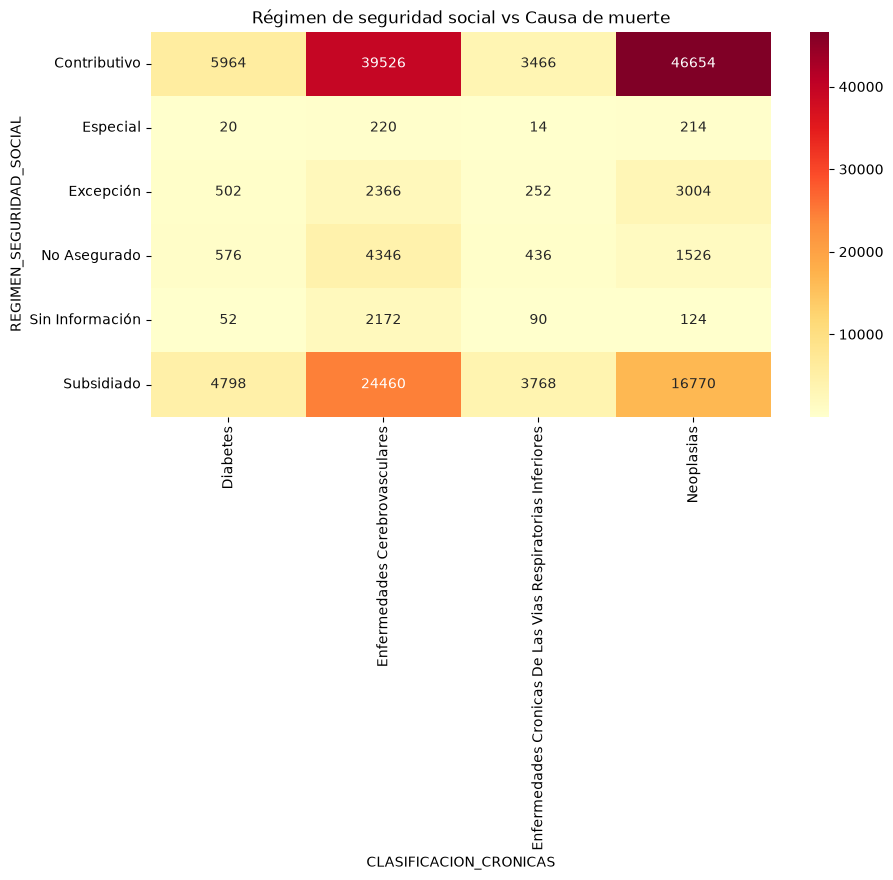

Chi2: 7110.55, p-valor: 0.000000, grados de libertad: 15


In [3]:
from scipy.stats import chi2_contingency
import seaborn as sns

# Tabla cruzada: régimen x causa
tabla_regimen = pd.crosstab(df_mortalidad['REGIMEN_SEGURIDAD_SOCIAL'], df_mortalidad['CLASIFICACION_CRONICAS'])
print(tabla_regimen)

# Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(tabla_regimen, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Régimen de seguridad social vs Causa de muerte')
plt.tight_layout()
plt.savefig('regimen_causa.png', dpi=150)
plt.show()

# Chi-cuadrado: ¿la causa de muerte depende del régimen?
chi2, p_valor, gl, esperado = chi2_contingency(tabla_regimen)
print(f"Chi2: {chi2:.2f}, p-valor: {p_valor:.6f}, grados de libertad: {gl}")